# AB Testing for Eniac Button

## Imports

In [14]:
import pandas as pd
import numpy as np

from scipy import stats
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests

import matplotlib.pyplot as plt

In [15]:
alpha = 0.05

In [16]:
from google.colab import files

uploaded = files.upload()

Saving eniac_a.csv to eniac_a (1).csv
Saving eniac_b.csv to eniac_b (1).csv
Saving eniac_c.csv to eniac_c (1).csv
Saving eniac_d.csv to eniac_d (1).csv


In [17]:
import os

os.listdir("/content")

['.config',
 'eniac_d.csv',
 'eniac_a (1).csv',
 'eniac_c (1).csv',
 'eniac_c.csv',
 'eniac_a.csv',
 'eniac_d (1).csv',
 'eniac_b.csv',
 'eniac_b (1).csv',
 'sample_data']

#### Step 1: Defining Hypotheses:<br>
**Null Hypothesis:** All differences between webpage click through rates were simply due to the random sampling<br><br>
**Alternative Hypothesis:** Some differences between webpage click through rates were not due to the random sampling

#### Step 2: Setting alpha:

In [18]:
page_a = pd.read_csv("eniac_a.csv")
page_b = pd.read_csv("eniac_b.csv")
page_c = pd.read_csv("eniac_c.csv")
page_d = pd.read_csv("eniac_d.csv")

Inspect the data

In [19]:
page_a.head()


,Element ID,Tag name,Name,No. clicks,Visible?,Snapshot information
0,48,h1,ENIAC,269,True,Homepage Version A - white SHOP NOW • http...
1,25,div,mySidebar,309,True,created 2021-09-14 • 14 days 0 hours 34 mi...
2,4,a,Mac,279,True,NaN
3,69,a,iPhone,246,True,NaN
4,105,a,Accessories,1235,True,NaN


In [20]:
page_a.shape

(57, 6)

In [21]:
page_a.columns.tolist()

['Element ID',
 'Tag name',
 'Name',
 'No. clicks',
 'Visible?',
 'Snapshot information']

#### Step 3: Gathering data from csvs and arranging in contingency table:

In [22]:
# Defining function for extracting data from csv
def get_clicks(version):
    page_df = pd.read_csv(f'eniac_{version.lower()}.csv')
    page_info = page_df['Snapshot information'][1]
    # Extract num visits from snapshot info
    visits = re.findall(pattern='(\d+) visits', string=page_info)[0]
    num_visits = int(visits)
    # Find element being tested
    button = page_df['Name'].isin(['SEE DEALS', 'SHOP NOW'])
    # Get clicked and didn't click
    clicked = page_df.loc[button, 'No. clicks'].iloc[0]
    didnt_click = num_visits - clicked
    return clicked, didnt_click

versions = ['A', 'B', 'C', 'D']

# Setting up empty contingency table
observed = pd.DataFrame(
    columns=versions,
    index=['Clicked', 'Didn\'t Click']
)

# Looping through versions grabbing click and didn't click counts
for version in versions:
    observed[version] = get_clicks(version)

observed

<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_3404/1965520189.py:6: SyntaxWarning: invalid escape sequence '\d'
  visits = re.findall(pattern='(\d+) visits', string=page_info)[0]


,A,B,C,D
Clicked,512,281,527,193
Didn't Click,24814,24466,24349,25040


#### Step 4: Calculating Statistical Significance

In [ ]:
# Calculating statistical significance
chisq, pvalue, df, expected = chi2_contingency(observed)
# Comparing with threshold
pvalue < alpha

np.True_

In [ ]:
pvalue

np.float64(2.716121660786871e-48)

Calculate CTR

In [23]:
ctr_results = pd.DataFrame(index=versions)

ctr_results['Clicks'] = observed.loc['Clicked']

ctr_results['Non_Clicks'] = observed.loc["Didn't Click"]

ctr_results['Visits'] = (
    ctr_results['Clicks'] + ctr_results['Non_Clicks']
)

ctr_results['CTR'] = (
    ctr_results['Clicks'] / ctr_results['Visits'] * 100
)

ctr_results

,Clicks,Non_Clicks,Visits,CTR
A,512,24814,25326,2.021638
B,281,24466,24747,1.135491
C,527,24349,24876,2.118508
D,193,25040,25233,0.764871


Find the highest observed CTR

In [24]:
best_version = ctr_results['CTR'].idxmax()

best_ctr = ctr_results['CTR'].max()

print("Version with highest observed CTR:", best_version)
print("Highest observed CTR:", round(best_ctr, 2), "%")

Version with highest observed CTR: C
Highest observed CTR: 2.12 %


This answers:

Which version has the highest CTR in the observed data?

But this is not yet a statistical conclusion.

For that, we need the Chi-square test.

Run Chi-square

In [25]:
chi2_stat, p_value, dof, expected = chi2_contingency(observed)

print("Chi-square statistic:", chi2_stat)
print("p-value:", p_value)
print("Degrees of freedom:", dof)

Chi-square statistic: 224.01877488058412
p-value: 2.7161216607868712e-48
Degrees of freedom: 3


In [26]:
if p_value < alpha:
    print("Reject H0: There is evidence that CTR differs across versions.")
else:
    print("Do not reject H0: There is insufficient evidence that CTR differs across versions.")

Reject H0: There is evidence that CTR differs across versions.


If the p-value is small:

The observed differences in CTR are difficult to explain by random variation alone, under the null hypothesis.

If the p-value is large:

The data does not provide sufficient evidence that the CTRs differ.

The overall Chi-square test does not tell you which version is better.

That is why we need pairwise testing.

Compare every version against every other version
A vs B ,
A vs C ,
A vs D ,
B vs C ,
B vs D ,
C vs D For each pair we compare the click and no clicks

Create pairwise comparisions

In [27]:
from itertools import combinations

pairwise_results = []

for version_1, version_2 in combinations(versions, 2):

    table = observed[[version_1, version_2]]

    chi2_stat, p_value, dof, expected = chi2_contingency(table)

    pairwise_results.append({
        'Version 1': version_1,
        'Version 2': version_2,
        'CTR 1': ctr_results.loc[version_1, 'CTR'],
        'CTR 2': ctr_results.loc[version_2, 'CTR'],
        'CTR Difference': (
            ctr_results.loc[version_1, 'CTR']
            - ctr_results.loc[version_2, 'CTR']
        ),
        'Chi-square': chi2_stat,
        'p-value': p_value
    })

pairwise_df = pd.DataFrame(pairwise_results)

pairwise_df

,Version 1,Version 2,CTR 1,CTR 2,CTR Difference,Chi-square,p-value
0,A,B,2.021638,1.135491,0.886147,62.493623,2.673088e-15
1,A,C,2.021638,2.118508,-0.096870,0.534210,4.648421e-01
2,A,D,2.021638,0.764871,1.256766,144.283184,3.080898e-33
3,B,C,1.135491,2.118508,-0.983017,74.229172,6.955480e-18
4,B,D,1.135491,0.764871,0.370620,17.876340,2.357337e-05
5,C,D,2.118508,0.764871,1.353636,161.117041,6.450501e-37


Correct for multiple comparisons

In [28]:
reject, p_adjusted, _, _ = multipletests(
    pairwise_df['p-value'],
    alpha=alpha,
    method='holm'
)

pairwise_df['Adjusted p-value'] = p_adjusted

pairwise_df['Significant'] = reject

pairwise_df

,Version 1,Version 2,CTR 1,CTR 2,CTR Difference,Chi-square,p-value,Adjusted p-value,Significant
0,A,B,2.021638,1.135491,0.886147,62.493623,2.673088e-15,8.019264e-15,True
1,A,C,2.021638,2.118508,-0.096870,0.534210,4.648421e-01,4.648421e-01,False
2,A,D,2.021638,0.764871,1.256766,144.283184,3.080898e-33,1.540449e-32,True
3,B,C,1.135491,2.118508,-0.983017,74.229172,6.955480e-18,2.782192e-17,True
4,B,D,1.135491,0.764871,0.370620,17.876340,2.357337e-05,4.714675e-05,True
5,C,D,2.118508,0.764871,1.353636,161.117041,6.450501e-37,3.870301e-36,True


Identify the strongest observed version

In [29]:
ctr_results.sort_values(
    by='CTR',
    ascending=False
)

,Clicks,Non_Clicks,Visits,CTR
C,527,24349,24876,2.118508
A,512,24814,25326,2.021638
B,281,24466,24747,1.135491
D,193,25040,25233,0.764871


Create a clear comparison summary

In [30]:
summary = pairwise_df[
    [
        'Version 1',
        'Version 2',
        'CTR 1',
        'CTR 2',
        'CTR Difference',
        'Adjusted p-value',
        'Significant'
    ]
]

summary

,Version 1,Version 2,CTR 1,CTR 2,CTR Difference,Adjusted p-value,Significant
0,A,B,2.021638,1.135491,0.886147,8.019264e-15,True
1,A,C,2.021638,2.118508,-0.096870,4.648421e-01,False
2,A,D,2.021638,0.764871,1.256766,1.540449e-32,True
3,B,C,1.135491,2.118508,-0.983017,2.782192e-17,True
4,B,D,1.135491,0.764871,0.370620,4.714675e-05,True
5,C,D,2.118508,0.764871,1.353636,3.870301e-36,True


Visualize CTR

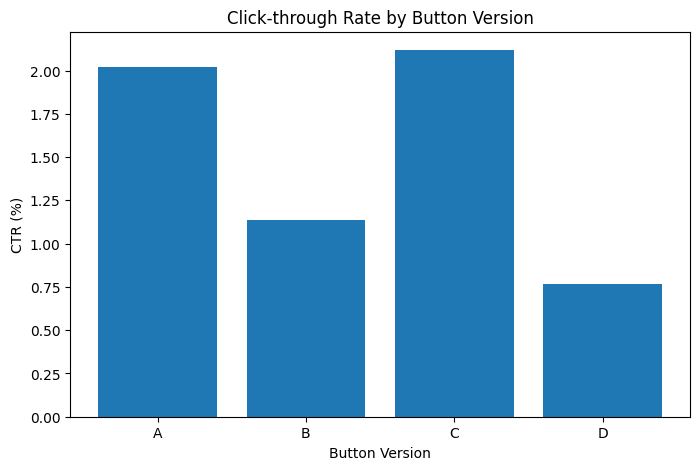

In [31]:
plt.figure(figsize=(8, 5))

plt.bar(
    ctr_results.index,
    ctr_results['CTR']
)

plt.xlabel("Button Version")

plt.ylabel("CTR (%)")

plt.title("Click-through Rate by Button Version")

plt.show()

Create an automated conclusion

In [33]:
def summarize_ab_test(ctr_results, pairwise_df, alpha=0.05):

    best_version = ctr_results['CTR'].idxmax()

    best_ctr = ctr_results['CTR'].max()

    overall_significant = p_value < alpha

    print("A/B TEST SUMMARY")
    print("----------------")
    print(f"Highest observed CTR: Version {best_version}")
    print(f"Highest observed CTR: {best_ctr:.2f}%")
    print(f"Overall Chi-square p-value: {p_value:.4f}")

    if overall_significant:
        print(
            "The overall test provides evidence "
            "that CTR differs across versions."
        )
    else:
        print(
            "The overall test does not provide sufficient "
            "evidence that CTR differs across versions."
        )

    print("\nPairwise comparisons:")
    print(pairwise_df[
        [
            'Version 1',
            'Version 2',
            'Adjusted p-value',
            'Significant'
        ]
    ])

In [34]:
summarize_ab_test(
    ctr_results,
    pairwise_df,
    alpha=alpha
)

A/B TEST SUMMARY
----------------
Highest observed CTR: Version C
Highest observed CTR: 2.12%
Overall Chi-square p-value: 0.0000
The overall test provides evidence that CTR differs across versions.

Pairwise comparisons:
  Version 1 Version 2  Adjusted p-value  Significant
0         A         B      8.019264e-15         True
1         A         C      4.648421e-01        False
2         A         D      1.540449e-32         True
3         B         C      2.782192e-17         True
4         B         D      4.714675e-05         True
5         C         D      3.870301e-36         True


Interpretation
A performs significantly better than C.
D performs significantly better than C.
A and D are not significantly different from each other.
B is not significantly different from A, C, or D after correction.

Final conclusion

Version A has the highest observed CTR at 8.93%, closely followed by Version D at 8.60%. The overall chi-square test shows that the four versions do not perform equally. The evidence specifically shows that Versions A and D perform significantly better than Version C. However, there is not enough statistical evidence to declare Version A significantly better than Version D.